In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import math
import matplotlib.pyplot as plt
import numpy as np
from omegaconf import OmegaConf
import os
import pandas as pd
import torch
from torch.autograd.functional import jacobian as autograd_jacobian
from torch.utils.data import RandomSampler, DataLoader
from tqdm.auto import tqdm
import wandb

from JacobianODE.jacobians import (
    load_config,
    initialize_config,
    seed_everything,
    make_trajectories,
    postprocess_data,
    create_dataloaders,
    load_run,
    load_checkpoint,
    select_best_model,
    DiagnosticMetrics,
)
from JacobianODE.jacobians.metrics import r2_score, normalized_mse as nmse_fn, mase
from JacobianODE.jacobians.tuning import select_from_wandb_runs
from JacobianODE.jacobians.lightning_base import loop_closure
from JacobianODE.models.latent_jacobian import LitLatentJacobianODE
from JacobianODE.fnn import loss_false, loss_amplification

torch.set_float32_matmul_precision('high')

## 1. Settings

Specify the W&B project, optional group, and save directory for checkpoints.

In [3]:
# ================================================================
# W&B project and group (EDIT THESE)
# ================================================================
WANDB_ENTITY  = "JacobianODE"

# spline coupling w/ partial obs (N100), vae KLD KLN LC ES sweep
WANDB_PROJECT = "Lorenz_IND0_N100_D1_NormTrue_T3__spline_coupling__JacobianODE"
WANDB_GROUP = "sweep_from_scratch_spline_coupling_lc_9vals__klNNone_1.0__klD0_0.0001_0.001_0.01_0.1_1__te0.0_enc_warmup_5_vaetrue"


WANDB_PROJECT_PATH = f"{WANDB_ENTITY}/{WANDB_PROJECT}"

# ================================================================
# Checkpoint save directory
# ================================================================
SAVE_DIR = "/orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/latent_jac_runs"

# ================================================================
# Known true Lyapunov exponents (for Lorenz: sigma=10, rho=28, beta=8/3)
# Set to None for wmtask — will be overridden after loading first run (Section 3)
# ================================================================
TRUE_LYAPUNOV = [0.91, 0.0, -14.57]  # None for wmtask (overridden from config)

print(f"W&B project: {WANDB_PROJECT_PATH}")
print(f"W&B group:   {WANDB_GROUP}")
print(f"Save dir:    {SAVE_DIR}")

W&B project: JacobianODE/Lorenz_IND0_N100_D1_NormTrue_T3__spline_coupling__JacobianODE
W&B group:   sweep_from_scratch_spline_coupling_lc_9vals__klNNone_1.0__klD0_0.0001_0.001_0.01_0.1_1__te0.0_enc_warmup_5_vaetrue
Save dir:    /orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/latent_jac_runs


## 2. Collect W&B Runs

In [4]:
api = wandb.Api()
try:
    run_filters = {"group": WANDB_GROUP} if WANDB_GROUP else None
    all_runs = api.runs(WANDB_PROJECT_PATH, filters=run_filters)
    msg = f"Found {len(all_runs)} total runs in {WANDB_PROJECT_PATH}"
    if WANDB_GROUP:
        msg += f" (group={WANDB_GROUP})"
    print(msg)
except Exception as e:
    print(f"Could not query project: {e}")
    all_runs = []

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/eisenaj/.netrc.


Found 108 total runs in JacobianODE/Lorenz_IND0_N100_D1_NormTrue_T3__spline_coupling__JacobianODE (group=sweep_from_scratch_spline_coupling_lc_9vals__klNNone_1.0__klD0_0.0001_0.001_0.01_0.1_1__te0.0_enc_warmup_5_vaetrue)


## 3. Filter Finished Runs

In [5]:
# Keep only runs that finished successfully (exclude running, crashed, etc.)
finished_runs = [r for r in all_runs if r.state == "finished"]
print(f"Finished runs: {len(finished_runs)} / {len(all_runs)}")

Finished runs: 106 / 108


## 4. Extract Config & Simulate Early Stopping with Patience = 2

For each finished run with `early_stopping_patience = 5`:
- Extract hyperparameters from config
- Pull the full `mean val loss` history
- Replay the `PercentEarlyStopping` logic with patience = 2 to find where training *would have* stopped
- Record both the actual best val loss (patience=5) and the counterfactual best val loss (patience=2)

In [6]:
def simulate_percent_early_stopping(val_losses, patience, percent_thresh=0.01, min_epochs=0):
    """Replay PercentEarlyStopping logic on a list of per-epoch val losses.
    
    Returns (stop_epoch, best_val_loss_up_to_stop) where stop_epoch is the
    0-indexed epoch at which training would have stopped, or len(val_losses)-1
    if it would never have triggered.
    """
    prev_loss = None
    wait_count = 0
    stop_epoch = None
    
    for epoch, loss in enumerate(val_losses):
        # Skip early stopping check until min_epochs
        if epoch < min_epochs:
            prev_loss = loss  # still update baseline
            continue
            
        # Handle NaN/Inf
        if not math.isfinite(loss):
            wait_count += 1
            if wait_count >= patience:
                stop_epoch = epoch
                break
            continue
        
        if prev_loss is None:
            prev_loss = loss
            continue
        
        # If prev_loss was NaN/Inf, reset baseline
        if not math.isfinite(prev_loss):
            prev_loss = loss
            wait_count = 0
            continue
        
        # Check percent improvement
        if prev_loss > loss:
            percent_improvement = (prev_loss - loss) / prev_loss
            if percent_improvement < percent_thresh:
                wait_count += 1
            else:
                wait_count = 0
        else:
            wait_count += 1
        
        prev_loss = loss
        
        if wait_count >= patience:
            stop_epoch = epoch
            break
    
    if stop_epoch is None:
        stop_epoch = len(val_losses) - 1
    
    # Best val loss up to the stop epoch (model checkpoint saves best)
    valid_losses = [l for l in val_losses[:stop_epoch + 1] if math.isfinite(l)]
    best_val_loss = min(valid_losses) if valid_losses else float('nan')
    
    return stop_epoch, best_val_loss

In [7]:
records = []

for run in tqdm(finished_runs, desc="Processing runs"):
    cfg = run.config
    
    # Extract early stopping patience
    es_cfg = cfg.get("training", {}).get("early_stopping", {})
    es_patience = es_cfg.get("early_stopping_patience", None)
    
    # Only keep runs with patience = 5
    if es_patience != 5:
        continue
    
    # Extract hyperparameters
    lightning_cfg = cfg.get("training", {}).get("lightning", {})
    loop_closure_weight = lightning_cfg.get("loop_closure_weight", None)
    kl_dyn_weight = lightning_cfg.get("kl_dyn_weight", None)
    kl_null_weight = lightning_cfg.get("kl_null_weight", None)
    
    # Normalize null/NaN kl_null_weight to kl_dyn_weight
    if kl_null_weight is not None:
        try:
            if not math.isfinite(float(kl_null_weight)):
                kl_null_weight = kl_dyn_weight
        except (ValueError, TypeError):
            kl_null_weight = kl_dyn_weight
    else:
        kl_null_weight = kl_dyn_weight
    
    model_cfg = cfg.get("model", {})
    kl_warmup_epochs = model_cfg.get("kl_warmup_epochs", None)
    
    percent_thresh = es_cfg.get("percent_thresh", 0.01)
    min_epochs = es_cfg.get("min_epochs", 0)
    
    # Pull full history for mean val loss and val/loop_closure_loss together
    history = list(run.scan_history(
        keys=["mean val loss", "val/loop_closure_loss", "_step"],
        page_size=10000,
    ))
    val_losses = []
    lc_losses = []
    for row in history:
        v = row.get("mean val loss")
        lc = row.get("val/loop_closure_loss")
        if v is not None:
            try:
                val_losses.append(float(v))
                lc_losses.append(float(lc) if lc is not None else float('nan'))
            except (ValueError, TypeError):
                continue
    
    if len(val_losses) == 0:
        continue
    
    # --- ES5: best checkpoint = argmin over all epochs ---
    actual_stop_epoch = len(val_losses) - 1
    valid_all = [(i, l) for i, l in enumerate(val_losses) if math.isfinite(l)]
    best_epoch_p5 = min(valid_all, key=lambda x: x[1])[0] if valid_all else 0
    best_val_loss_p5 = val_losses[best_epoch_p5] if valid_all else float('nan')
    lc_loss_at_best_p5 = lc_losses[best_epoch_p5] if best_epoch_p5 < len(lc_losses) else float('nan')
    
    # --- ES2: simulate stopping, best checkpoint = argmin up to stop epoch ---
    stop_epoch_p2, best_val_loss_p2 = simulate_percent_early_stopping(
        val_losses, patience=2, percent_thresh=percent_thresh, min_epochs=min_epochs
    )
    valid_p2 = [(i, l) for i, l in enumerate(val_losses[:stop_epoch_p2 + 1]) if math.isfinite(l)]
    best_epoch_p2 = min(valid_p2, key=lambda x: x[1])[0] if valid_p2 else 0
    lc_loss_at_best_p2 = lc_losses[best_epoch_p2] if best_epoch_p2 < len(lc_losses) else float('nan')
    
    # --- Choppiness metrics (computed on finite values over full training) ---
    finite_losses = [(i, l) for i, l in enumerate(val_losses) if math.isfinite(l)]
    if len(finite_losses) >= 2:
        fl_vals = [l for _, l in finite_losses]
        diffs = [abs(fl_vals[i+1] - fl_vals[i]) for i in range(len(fl_vals) - 1)]
        signed_diffs = [fl_vals[i+1] - fl_vals[i] for i in range(len(fl_vals) - 1)]
        
        total_variation = sum(diffs)
        net_improvement = fl_vals[0] - min(fl_vals)
        # Normalized TV: total path length relative to net improvement achieved
        # (1.0 = perfectly monotone descent; higher = choppier)
        norm_total_variation = total_variation / net_improvement if net_improvement > 1e-12 else float('nan')
        
        # Fraction of steps where loss did not decrease
        frac_non_improving = sum(1 for d in signed_diffs if d >= 0) / len(signed_diffs)
        
        # Mean absolute change normalized by mean loss (scale-free roughness)
        mean_loss = sum(fl_vals) / len(fl_vals)
        mean_abs_change_norm = (sum(diffs) / len(diffs)) / mean_loss if mean_loss > 1e-12 else float('nan')
    else:
        norm_total_variation = float('nan')
        frac_non_improving = float('nan')
        mean_abs_change_norm = float('nan')
    
    records.append({
        "run_id": run.id,
        "run_name": run.name,
        "loop_closure_weight": loop_closure_weight,
        "kl_dyn_weight": kl_dyn_weight,
        "kl_null_weight": kl_null_weight,
        "kl_warmup_epochs": kl_warmup_epochs,
        "es_patience": es_patience,
        "percent_thresh": percent_thresh,
        "total_epochs": len(val_losses),
        "stop_epoch_p5": actual_stop_epoch,
        "best_epoch_p5": best_epoch_p5,
        "best_val_loss_p5": best_val_loss_p5,
        "lc_loss_at_best_p5": lc_loss_at_best_p5,
        "stop_epoch_p2": stop_epoch_p2,
        "best_epoch_p2": best_epoch_p2,
        "best_val_loss_p2": best_val_loss_p2,
        "lc_loss_at_best_p2": lc_loss_at_best_p2,
        # Choppiness metrics
        "norm_total_variation": norm_total_variation,
        "frac_non_improving": frac_non_improving,
        "mean_abs_change_norm": mean_abs_change_norm,
    })

print(f"Collected {len(records)} runs with early_stopping_patience = 5")

Processing runs:   0%|          | 0/106 [00:00<?, ?it/s]

Collected 106 runs with early_stopping_patience = 5


## 5. Results DataFrame

In [8]:
df = pd.DataFrame(records)

# Add derived columns
df["epochs_saved"] = df["stop_epoch_p5"] - df["stop_epoch_p2"]
df["val_loss_diff"] = df["best_val_loss_p2"] - df["best_val_loss_p5"]
df["val_loss_pct_diff"] = (df["val_loss_diff"] / df["best_val_loss_p5"]) * 100

print(f"Shape: {df.shape}")
df

Shape: (106, 23)


,run_id,run_name,loop_closure_weight,kl_dyn_weight,kl_null_weight,kl_warmup_epochs,es_patience,percent_thresh,total_epochs,stop_epoch_p5,...,stop_epoch_p2,best_epoch_p2,best_val_loss_p2,lc_loss_at_best_p2,norm_total_variation,frac_non_improving,mean_abs_change_norm,epochs_saved,val_loss_diff,val_loss_pct_diff
0,9lwpgvwh,"MLP__hidden_dim_[256, 1024, 2048, 2048]__num_l...",0.000,0.0000,0.0000,10,5,0.01,93,92,...,23,21,0.010355,11.171926,1.317591,0.478261,0.219928,69,0.008346,415.572458
1,gluxv390,"MLP__hidden_dim_[256, 1024, 2048, 2048]__num_l...",0.000,0.0000,0.0000,0,5,0.01,61,60,...,23,21,0.010355,11.171926,1.292104,0.466667,0.220308,37,0.007620,278.575559
2,r4dvlgqn,"MLP__hidden_dim_[256, 1024, 2048, 2048]__num_l...",0.000,0.0000,1.0000,0,5,0.01,95,94,...,20,16,0.012959,29.031771,1.541479,0.457447,0.230885,74,0.010973,552.771077
3,ck9rrf7a,"MLP__hidden_dim_[256, 1024, 2048, 2048]__num_l...",0.000,0.0000,1.0000,10,5,0.01,96,95,...,23,21,0.009100,11.779331,1.365370,0.494737,0.217514,72,0.006490,248.607372
4,kx529s06,"MLP__hidden_dim_[256, 1024, 2048, 2048]__num_l...",0.000,0.0001,0.0001,10,5,0.01,95,94,...,30,28,0.004894,10.299989,1.319829,0.446809,0.220032,64,0.002863,140.923521
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,l8157jn8,"MLP__hidden_dim_[256, 1024, 2048, 2048]__num_l...",0.001,0.0001,0.0001,10,5,0.01,63,62,...,36,32,0.008219,0.042092,1.535641,0.435484,0.232592,26,0.005392,190.683516
102,1h7ts99r,"MLP__hidden_dim_[256, 1024, 2048, 2048]__num_l...",0.001,0.0001,1.0000,0,5,0.01,68,67,...,17,15,0.042946,0.132951,1.760092,0.402985,0.218243,50,0.040443,1616.157285
103,52zhpbgn,"MLP__hidden_dim_[256, 1024, 2048, 2048]__num_l...",0.001,0.0001,1.0000,10,5,0.01,51,50,...,20,18,0.024030,0.037627,1.628675,0.380000,0.231816,30,0.019369,415.602112
104,v78cd9ca,"MLP__hidden_dim_[256, 1024, 2048, 2048]__num_l...",0.001,0.0010,0.0010,0,5,0.01,75,74,...,17,13,0.029064,0.003228,2.541619,0.500000,0.341703,57,0.025866,808.775925


## 6. Val Loss vs Hyperparameters (ES5 vs ES2)

After LC loss filter (threshold=1.732):
  ES5: 66 / 106 runs kept
  ES2: 80 / 106 runs kept


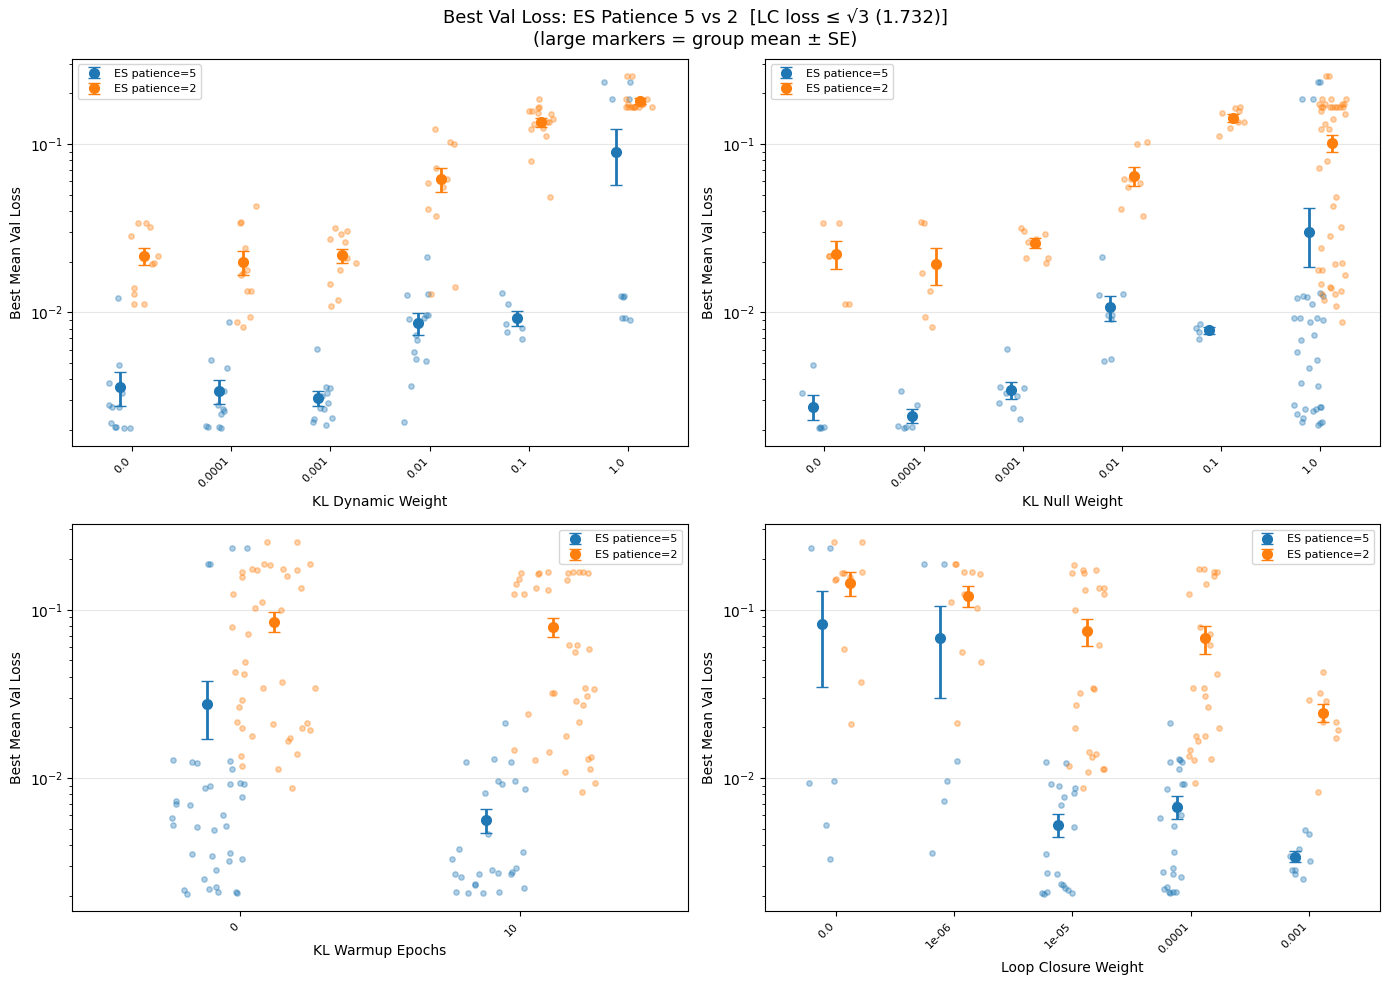

In [ ]:
# ================================================================
# Filter: drop runs where val loop closure loss > sqrt(3)
# Applies the ES5 LC loss to the ES5 series and the ES2 LC loss to the ES2 series.
# ================================================================
LC_LOSS_FILTER = True
LC_LOSS_THRESHOLD = math.sqrt(3)

df_p5 = df.copy()
df_p2 = df.copy()
if LC_LOSS_FILTER:
    df_p5 = df_p5[df_p5["lc_loss_at_best_p5"].apply(lambda x: math.isfinite(x) and x <= LC_LOSS_THRESHOLD)]
    df_p2 = df_p2[df_p2["lc_loss_at_best_p2"].apply(lambda x: math.isfinite(x) and x <= LC_LOSS_THRESHOLD)]
    print(f"After LC loss filter (threshold={LC_LOSS_THRESHOLD:.3f}):")
    print(f"  ES5: {len(df_p5)} / {len(df)} runs kept")
    print(f"  ES2: {len(df_p2)} / {len(df)} runs kept")

# ================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

params = [
    ("kl_dyn_weight",       "KL Dynamic Weight"),
    ("kl_null_weight",      "KL Null Weight"),
    ("kl_warmup_epochs",    "KL Warmup Epochs"),
    ("loop_closure_weight", "Loop Closure Weight"),
]

rng = np.random.default_rng(42)

for ax, (col, label) in zip(axes.flat, params):
    categories = sorted(df[col].unique())
    cat_to_pos = {c: i for i, c in enumerate(categories)}
    n_cats = len(categories)

    for src_df, offset, loss_col, lc_col, color, es_label in [
        (df_p5, -0.12, "best_val_loss_p5", "lc_loss_at_best_p5", "C0", "ES patience=5"),
        (df_p2,  0.12, "best_val_loss_p2", "lc_loss_at_best_p2", "C1", "ES patience=2"),
    ]:
        positions = np.array([cat_to_pos[v] for v in src_df[col]])
        jitter = rng.uniform(-0.15, 0.15, size=len(src_df))

        # Individual points
        ax.scatter(positions + jitter + offset, src_df[loss_col],
                   alpha=0.35, s=15, color=color, zorder=2)

        # Group means ± SE
        first = True
        for i, cat in enumerate(categories):
            mask = src_df[col] == cat
            vals = src_df.loc[mask, loss_col].dropna()
            if len(vals) == 0:
                continue
            mean = vals.mean()
            se = vals.sem()
            ax.errorbar(i + offset, mean, yerr=se,
                        fmt="o", color=color, markersize=7,
                        capsize=4, linewidth=2, zorder=3,
                        label=es_label if first else None)
            first = False

    ax.set_xticks(range(n_cats))
    ax.set_xticklabels([str(c) for c in categories], rotation=45, ha="right", fontsize=8)
    ax.set_xlim(-0.6, n_cats - 0.4)
    ax.set_xlabel(label)
    ax.set_ylabel("Best Mean Val Loss")
    ax.set_yscale("log")
    ax.legend(fontsize=8)
    ax.grid(True, axis="y", alpha=0.3)

filter_str = f"LC loss ≤ √3 ({LC_LOSS_THRESHOLD:.3f})" if LC_LOSS_FILTER else "no LC loss filter"
fig.suptitle(f"Best Val Loss: ES Patience 5 vs 2  [{filter_str}]\n(large markers = group mean ± SE)", fontsize=13)
fig.tight_layout()
plt.show()

After kl_dyn_weight ≤ 0.001 + kl_null_weight ≤ 0.001 filter:
  ES5: 20 / 66 runs kept
  ES2: 20 / 80 runs kept

ES5 — mean val loss by kl_warmup_epochs:
  warmup=   0: mean=0.0033  n=11
  warmup=  10: mean=0.0025  n=9

ES2 — mean val loss by kl_warmup_epochs:
  warmup=   0: mean=0.0227  n=11
  warmup=  10: mean=0.0231  n=9


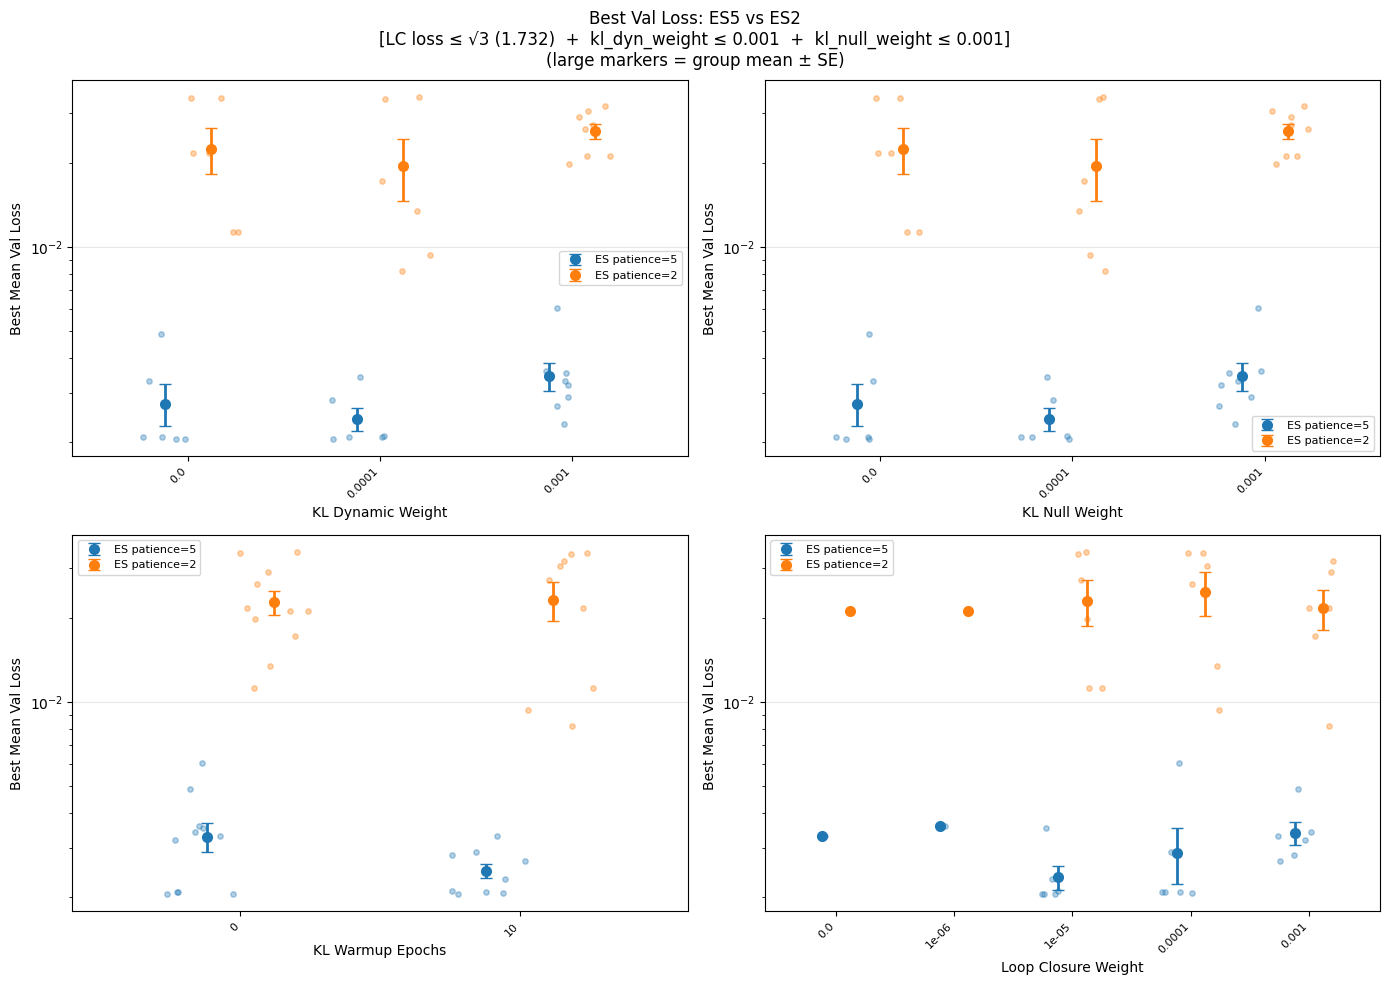

In [43]:
# ================================================================
# Same plot as above, but additionally filtered to
# kl_dyn_weight <= KL_DYN_WEIGHT_THRESHOLD
# kl_null_weight <= KL_NULL_WEIGHT_THRESHOLD
# ================================================================
KL_DYN_WEIGHT_THRESHOLD  = 0.001
KL_NULL_WEIGHT_THRESHOLD = 0.001

df_p5_kld = df_p5[
    (df_p5["kl_dyn_weight"]  <= KL_DYN_WEIGHT_THRESHOLD) &
    (df_p5["kl_null_weight"] <= KL_NULL_WEIGHT_THRESHOLD)
]
df_p2_kld = df_p2[
    (df_p2["kl_dyn_weight"]  <= KL_DYN_WEIGHT_THRESHOLD) &
    (df_p2["kl_null_weight"] <= KL_NULL_WEIGHT_THRESHOLD)
]
print(f"After kl_dyn_weight ≤ {KL_DYN_WEIGHT_THRESHOLD} + kl_null_weight ≤ {KL_NULL_WEIGHT_THRESHOLD} filter:")
print(f"  ES5: {len(df_p5_kld)} / {len(df_p5)} runs kept")
print(f"  ES2: {len(df_p2_kld)} / {len(df_p2)} runs kept")

# Print warmup epoch comparison for reference
for es_label, src_df, loss_col in [
    ("ES5", df_p5_kld, "best_val_loss_p5"),
    ("ES2", df_p2_kld, "best_val_loss_p2"),
]:
    print(f"\n{es_label} — mean val loss by kl_warmup_epochs:")
    for we in sorted(src_df["kl_warmup_epochs"].unique()):
        vals = src_df.loc[src_df["kl_warmup_epochs"] == we, loss_col].dropna()
        print(f"  warmup={we:>4g}: mean={vals.mean():.4f}  n={len(vals)}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

params = [
    ("kl_dyn_weight",       "KL Dynamic Weight"),
    ("kl_null_weight",      "KL Null Weight"),
    ("kl_warmup_epochs",    "KL Warmup Epochs"),
    ("loop_closure_weight", "Loop Closure Weight"),
]

rng2 = np.random.default_rng(42)

for ax, (col, label) in zip(axes.flat, params):
    # Only show categories present in the filtered data (union of both ES sets)
    categories = sorted(set(df_p5_kld[col].unique()) | set(df_p2_kld[col].unique()))
    cat_to_pos = {c: i for i, c in enumerate(categories)}
    n_cats = len(categories)

    for src_df, offset, loss_col, color, es_label in [
        (df_p5_kld, -0.12, "best_val_loss_p5", "C0", "ES patience=5"),
        (df_p2_kld,  0.12, "best_val_loss_p2", "C1", "ES patience=2"),
    ]:
        positions = np.array([cat_to_pos[v] for v in src_df[col]])
        jitter = rng2.uniform(-0.15, 0.15, size=len(src_df))

        ax.scatter(positions + jitter + offset, src_df[loss_col],
                   alpha=0.35, s=15, color=color, zorder=2)

        first = True
        for i, cat in enumerate(categories):
            mask = src_df[col] == cat
            vals = src_df.loc[mask, loss_col].dropna()
            if len(vals) == 0:
                continue
            mean = vals.mean()
            se = vals.sem()
            ax.errorbar(i + offset, mean, yerr=se,
                        fmt="o", color=color, markersize=7,
                        capsize=4, linewidth=2, zorder=3,
                        label=es_label if first else None)
            first = False

    ax.set_xticks(range(n_cats))
    ax.set_xticklabels([str(c) for c in categories], rotation=45, ha="right", fontsize=8)
    ax.set_xlim(-0.6, n_cats - 0.4)
    ax.set_xlabel(label)
    ax.set_ylabel("Best Mean Val Loss")
    ax.set_yscale("log")
    ax.legend(fontsize=8)
    ax.grid(True, axis="y", alpha=0.3)

filter_str = f"LC loss ≤ √3 ({LC_LOSS_THRESHOLD:.3f})" if LC_LOSS_FILTER else "no LC loss filter"
fig.suptitle(
    f"Best Val Loss: ES5 vs ES2\n"
    f"[{filter_str}  +  kl_dyn_weight ≤ {KL_DYN_WEIGHT_THRESHOLD}"
    f"  +  kl_null_weight ≤ {KL_NULL_WEIGHT_THRESHOLD}]\n"
    f"(large markers = group mean ± SE)",
    fontsize=12,
)
fig.tight_layout()
plt.show()

## 7. Loss Curve Choppiness vs Hyperparameters

Three metrics quantify how non-monotone the val loss curve is over the full training run:

| Metric | Definition | Interpretation |
|---|---|---|
| **Normalized Total Variation (NTV)** | `Σ\|ΔL\| / (L_first − L_best)` | 1.0 = perfectly monotone; higher = more backtracking relative to net improvement |
| **Fraction non-improving steps** | fraction of epochs where `L(t) ≥ L(t−1)` | 0 = always improving; ~0.5 = random walk |
| **Mean abs change / mean loss** | `mean(\|ΔL\|) / mean(L)` | Scale-free per-epoch roughness |

A choppy curve is the reason ES5 outperforms ES2: the model needs patience to wait through temporary upswings.

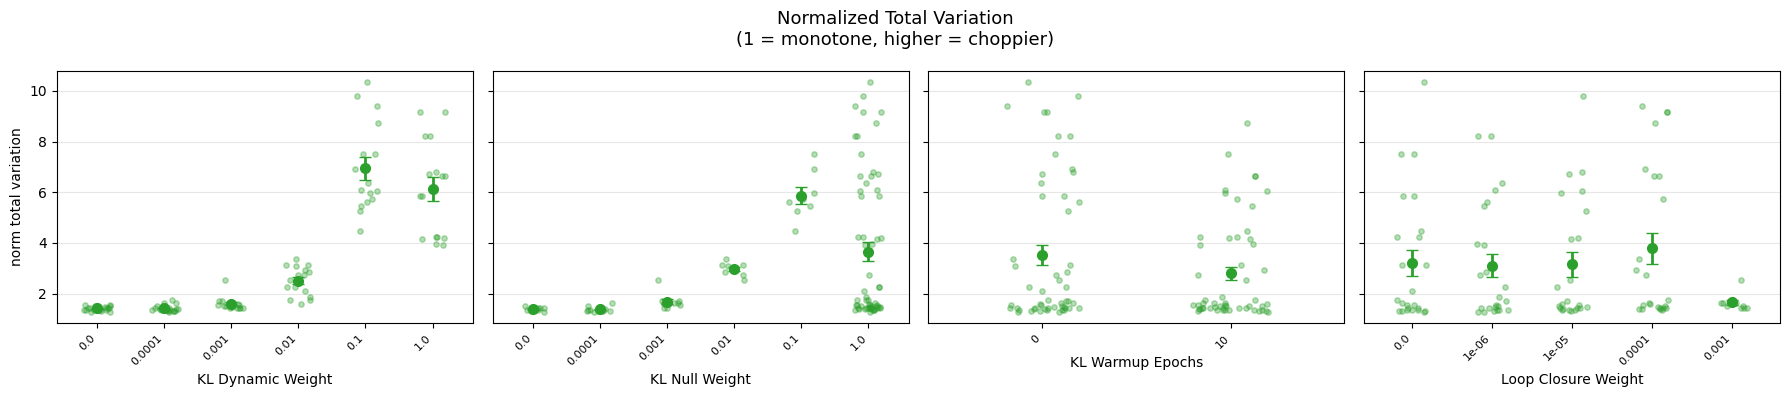

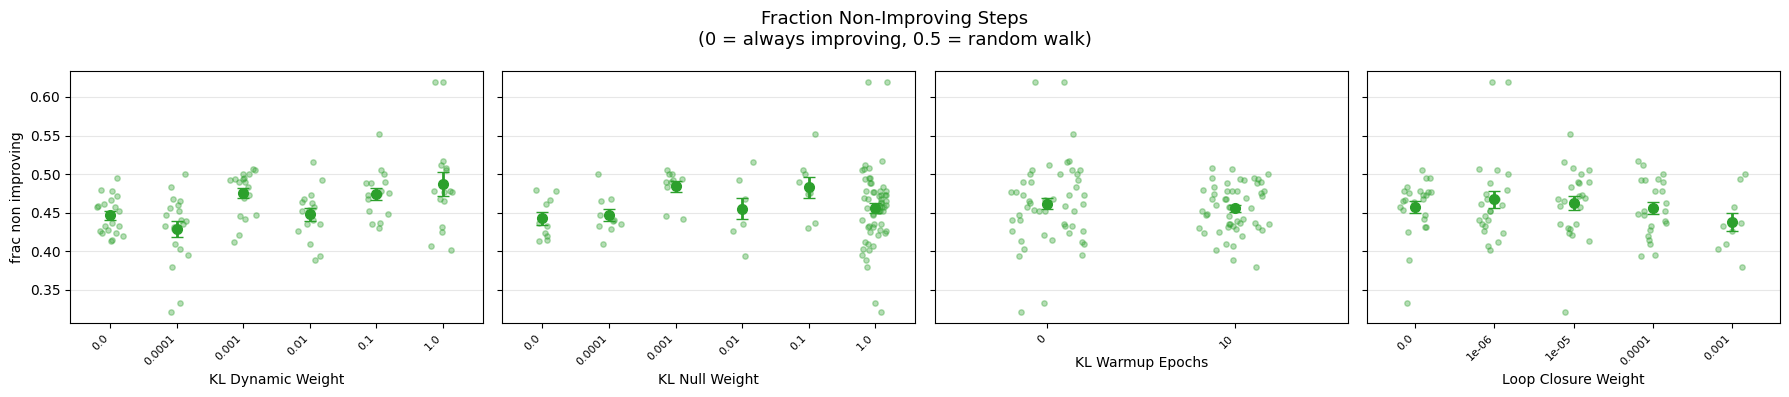

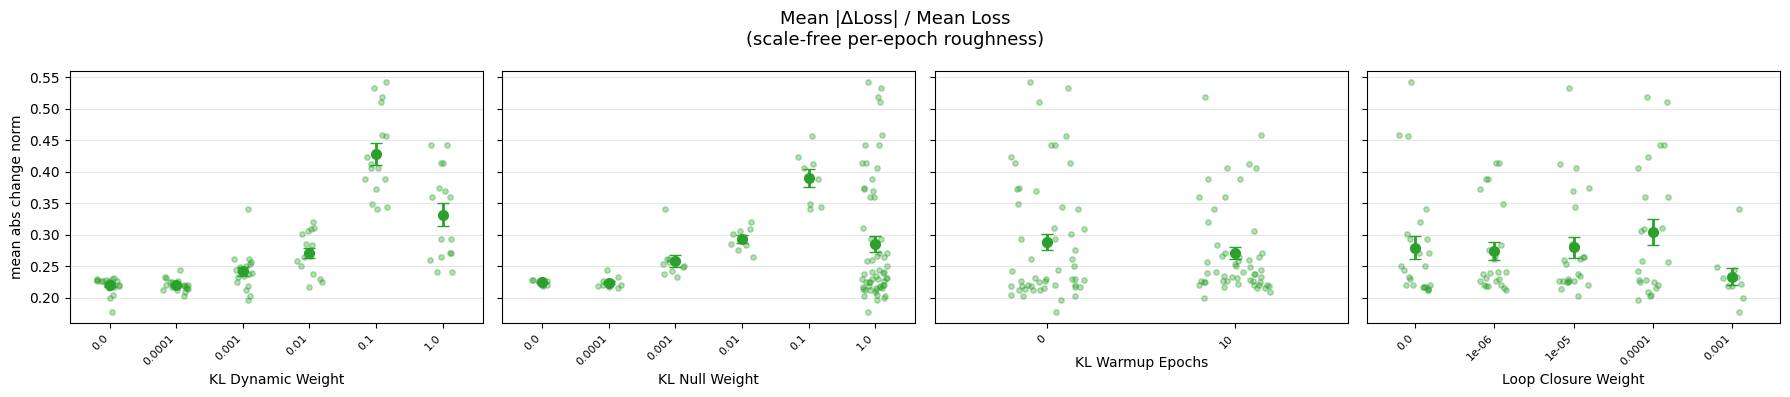

In [10]:
choppiness_metrics = [
    ("norm_total_variation",  "Normalized Total Variation\n(1 = monotone, higher = choppier)"),
    ("frac_non_improving",    "Fraction Non-Improving Steps\n(0 = always improving, 0.5 = random walk)"),
    ("mean_abs_change_norm",  "Mean |ΔLoss| / Mean Loss\n(scale-free per-epoch roughness)"),
]

hparams = [
    ("kl_dyn_weight",       "KL Dynamic Weight"),
    ("kl_null_weight",      "KL Null Weight"),
    ("kl_warmup_epochs",    "KL Warmup Epochs"),
    ("loop_closure_weight", "Loop Closure Weight"),
]

rng2 = np.random.default_rng(0)

for chop_col, chop_label in choppiness_metrics:
    fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
    fig.suptitle(chop_label, fontsize=13)

    for ax, (col, label) in zip(axes, hparams):
        categories = sorted(df[col].unique())
        cat_to_pos = {c: i for i, c in enumerate(categories)}
        n_cats = len(categories)

        valid = df[chop_col].notna()
        positions = np.array([cat_to_pos[v] for v in df.loc[valid, col]])
        jitter = rng2.uniform(-0.2, 0.2, size=valid.sum())

        ax.scatter(positions + jitter, df.loc[valid, chop_col],
                   alpha=0.35, s=15, color="C2", zorder=2)

        # Group mean ± SE
        for i, cat in enumerate(categories):
            mask = valid & (df[col] == cat)
            vals = df.loc[mask, chop_col].dropna()
            if len(vals) == 0:
                continue
            ax.errorbar(i, vals.mean(), yerr=vals.sem(),
                        fmt="o", color="C2", markersize=7,
                        capsize=4, linewidth=2, zorder=3)

        ax.set_xticks(range(n_cats))
        ax.set_xticklabels([str(c) for c in categories], rotation=45, ha="right", fontsize=8)
        ax.set_xlim(-0.6, n_cats - 0.4)
        ax.set_xlabel(label)
        ax.grid(True, axis="y", alpha=0.3)

    axes[0].set_ylabel(chop_col.replace("_", " "))
    fig.tight_layout()
    plt.show()

In [21]:
df_lc_valid = df[df['lc_loss_at_best_p5'] <= math.sqrt(3)]
best_run = df_lc_valid.loc[df_lc_valid['best_val_loss_p5'].idxmin()]


In [28]:
df_lc_valid = df[df['lc_loss_at_best_p5'] <= math.sqrt(3)]
# Find the run with same kl_null_weight, kl_dyn_weight, and loop_closure_weight as best_run, but kl_warmup_epochs = 10
ref_row = df_lc_valid.loc[df_lc_valid['best_val_loss_p5'].idxmin()]
mask = (
    (df["kl_null_weight"] == ref_row["kl_null_weight"]) &
    (df["kl_dyn_weight"] == ref_row["kl_dyn_weight"]) &
    (df["loop_closure_weight"] == ref_row["loop_closure_weight"]) &
    (df["kl_warmup_epochs"] == 10)
)
matching_runs = df[mask]
if len(matching_runs) == 0:
    best_run_kl_warmup = None  # or handle how you prefer if not found
else:
    # Arbitrarily pick first matching, or pick lowest loss if more than one
    best_run_kl_warmup = matching_runs.loc[matching_runs['best_val_loss_p5'].idxmin()]


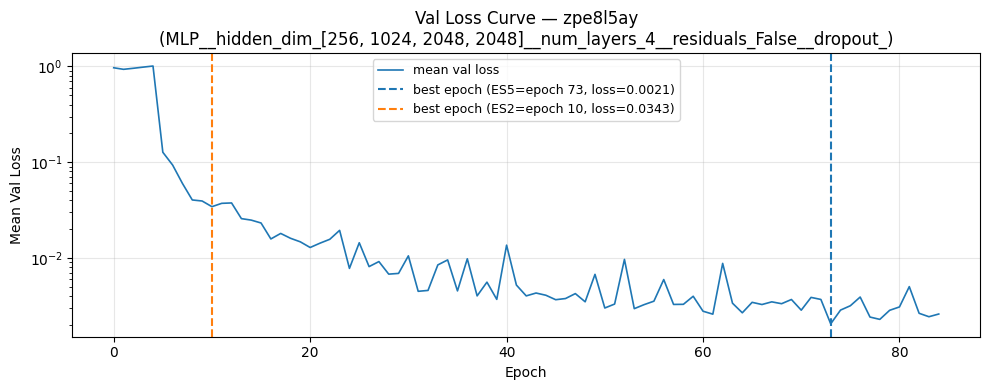

In [15]:
# Plot mean val loss over epochs for the best run (lowest best_val_loss_p5 with LC filter)
best_row = df_lc_valid.loc[df_lc_valid['best_val_loss_p5'].idxmin()]
best_run_id = best_row['run_id']

best_run = next(r for r in all_runs if r.id == best_run_id)
history = list(best_run.scan_history(keys=["mean val loss", "epoch", "_step"], page_size=10000))
rows = [(row["epoch"], float(row["mean val loss"]))
        for row in history
        if row.get("mean val loss") is not None and row.get("epoch") is not None]
epochs_x, val_losses_best = zip(*rows)

# best_epoch_p5/p2 are indices into val_losses — map to actual epoch number
epoch_p5 = epochs_x[int(best_row['best_epoch_p5'])]
epoch_p2 = epochs_x[int(best_row['best_epoch_p2'])]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(epochs_x, val_losses_best, lw=1.2, color="C0", label="mean val loss")
ax.axvline(epoch_p5, color="C0", linestyle="--", lw=1.5,
           label=f"best epoch (ES5=epoch {epoch_p5}, loss={best_row['best_val_loss_p5']:.4f})")
ax.axvline(epoch_p2, color="C1", linestyle="--", lw=1.5,
           label=f"best epoch (ES2=epoch {epoch_p2}, loss={best_row['best_val_loss_p2']:.4f})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean Val Loss")
ax.set_yscale("log")
ax.set_title(f"Val Loss Curve — {best_run_id}\n({best_row['run_name'][:80]})")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

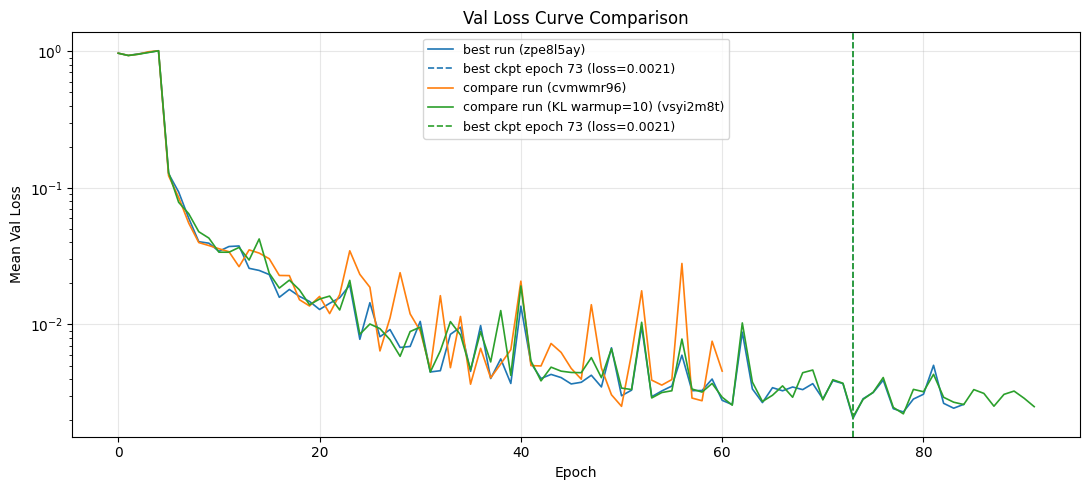

In [33]:
COMPARE_GROUP   = "sweep_from_scratch_spline_coupling_lc_1vals__klNnull__klD0.0001__te0.0_enc_warmup_5_vaetrue"
COMPARE_RUN_ID  = "cvmwmr96"
COMPARE_RUN_ID_KL_WARMUP = best_run_kl_warmup['run_id']

compare_run = api.run(f"{WANDB_PROJECT_PATH}/{COMPARE_RUN_ID}")
compare_run_kl_warmup = api.run(f"{WANDB_PROJECT_PATH}/{COMPARE_RUN_ID_KL_WARMUP}")

def fetch_val_loss_curve(run):
    history = list(run.scan_history(keys=["mean val loss", "epoch"], page_size=10000))
    rows = [(row["epoch"], float(row["mean val loss"]))
            for row in history
            if row.get("mean val loss") is not None and row.get("epoch") is not None]
    if not rows:
        return [], []
    epochs_x, losses = zip(*rows)
    return list(epochs_x), list(losses)

# Best run from previous cell
best_row = df_lc_valid.loc[df_lc_valid['best_val_loss_p5'].idxmin()]
best_run = next(r for r in all_runs if r.id == best_row['run_id'])
epochs_best, losses_best = fetch_val_loss_curve(best_run)
epoch_p5_best = epochs_best[int(best_row['best_epoch_p5'])]

# Comparison run
epochs_cmp, losses_cmp = fetch_val_loss_curve(compare_run)
# epoch_p5_cmp = epochs_cmp[int(compare_run['best_epoch_p5'])]
epochs_cmp_kl_warmup, losses_cmp_kl_warmup = fetch_val_loss_curve(compare_run_kl_warmup)
epoch_p5_cmp_kl_warmup = epochs_cmp_kl_warmup[int(best_run_kl_warmup['best_epoch_p5'])]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(epochs_best, losses_best, lw=1.2, color="C0", label=f"best run ({best_row['run_id']})")
ax.axvline(epoch_p5_best, color="C0", linestyle="--", lw=1.2,
           label=f"best ckpt epoch {epoch_p5_best} (loss={best_row['best_val_loss_p5']:.4f})")

ax.plot(epochs_cmp, losses_cmp, lw=1.2, color="C1", label=f"compare run ({COMPARE_RUN_ID})")
# ax.axvline(epoch_p5_cmp, color="C1", linestyle="--", lw=1.2,
#            label=f"best ckpt epoch {epoch_p5_cmp} (loss={best_row['best_val_loss_p5']:.4f})")

ax.plot(epochs_cmp_kl_warmup, losses_cmp_kl_warmup, lw=1.2, color="C2", label=f"compare run (KL warmup=10) ({COMPARE_RUN_ID_KL_WARMUP})")
ax.axvline(epoch_p5_cmp_kl_warmup, color="C2", linestyle="--", lw=1.2,
           label=f"best ckpt epoch {epoch_p5_cmp_kl_warmup} (loss={best_row['best_val_loss_p5']:.4f})")

ax.set_xlabel("Epoch")
ax.set_ylabel("Mean Val Loss")
ax.set_yscale("log")
ax.set_title("Val Loss Curve Comparison")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

Loading run zpe8l5ay from JacobianODE/Lorenz_IND0_N100_D1_NormTrue_T3__spline_coupling__JacobianODE ...


Sequence Indices:   0%|          | 0/1056 [00:00<?, ?it/s]

Train dataset shape: torch.Size([23232, 45, 100])
Validation dataset shape: torch.Size([7392, 45, 100])
Test dataset shape: torch.Size([3168, 45, 100])
Train trajectories dataset shape: torch.Size([22, 1101, 100])
Validation trajectories dataset shape: torch.Size([7, 1101, 100])
Test trajectories dataset shape: torch.Size([3, 1101, 100])
Loading checkpoint epoch=73-step=14800.ckpt...
HTML report will be saved to: ../reports/2026-03-26_21-40-07__sweep_from_scratch_spline_coupling_lc_9vals__klNNone_1.0__klD0_0.0001_0.001_0.01_0.1_1__te0.0_enc_warmup_5_vaetrue__zpe8l5ay.html
Skipping 'sweep_overview': provide wandb_group or precomputed sweep_diagnostics.
Computing reconstruction ...


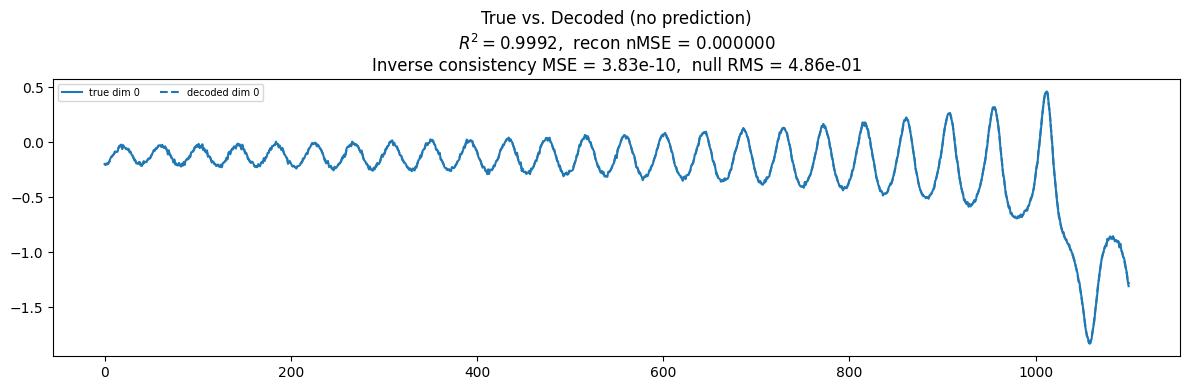

Computing MASE ...


MASE batches:   0%|          | 0/10 [00:00<?, ?it/s]

Teacher-forced MASE: 0.4259
Free-running MASE:   0.5993


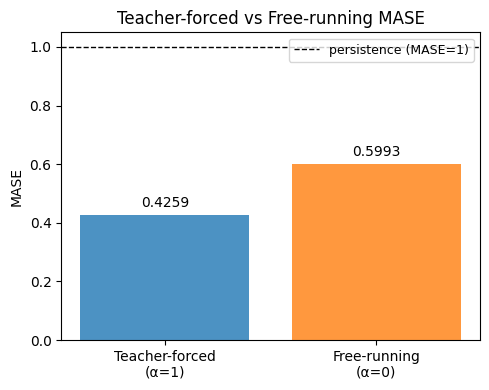

Computing latent utilization ...
Entropy-based utilization: 0.760
Null subspace mean RMS: 4.069147e-01


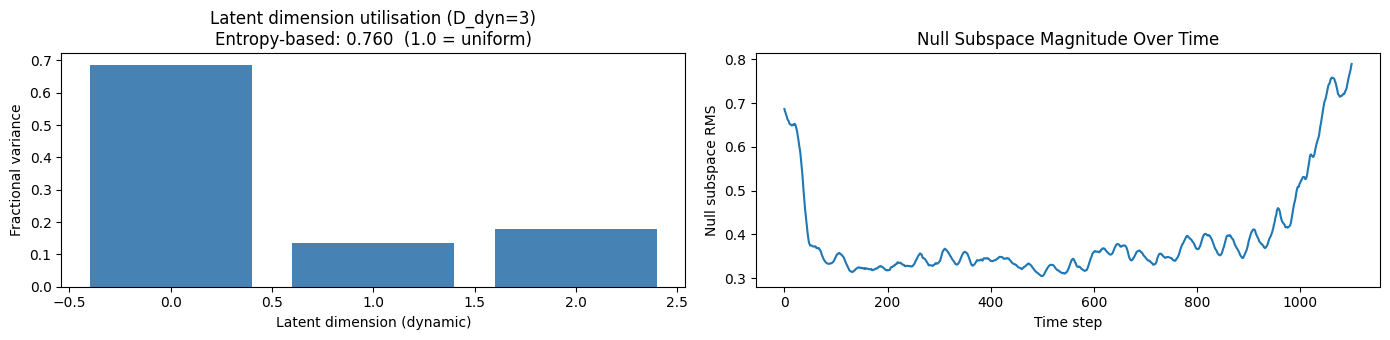

Computing Lyapunov exponents ...
  Computing full-trajectory Lyapunov (3 test trajs, T=1101) ...
    Traj 0: [ 0.21224885  0.04121457 -5.490267  ]
    Traj 1: [ 0.4224601  -0.09620276 -5.513213  ]
    Traj 2: [ 0.42643997 -0.06592081 -5.5317206 ]
Predicted Lyapunov exponents (batch+burn-in, 128 windowed trajs):
  λ_1 = +0.5190 ± 0.3434
  λ_2 = -0.4618 ± 0.3247
  λ_3 = -4.8157 ± 0.8931
Predicted Lyapunov exponents (full-length, 3 test trajs):
  λ_1 = +0.3537 ± 0.1225
  λ_2 = -0.0403 ± 0.0722
  λ_3 = -5.5117 ± 0.0208
True:      [0.91, 0.0, -14.57]
Empirical Lyapunov exponents (mean ± std):
  λ_1 = +0.3846 ± 0.0251
  λ_2 = -0.1716 ± 0.0444
  λ_3 = -13.8799 ± 0.0398


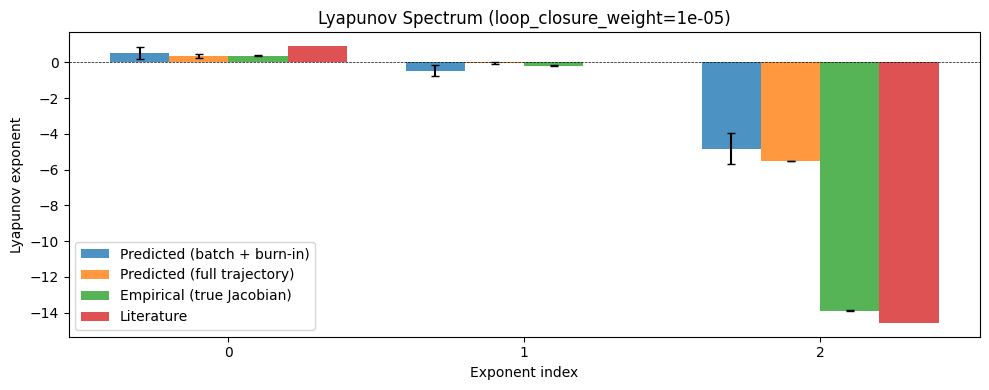

Mean KY dim (predicted): 2.057 ± 0.008
Mean KY dim (empirical): 2.015 ± 0.002
KY dim (theory):         2.062


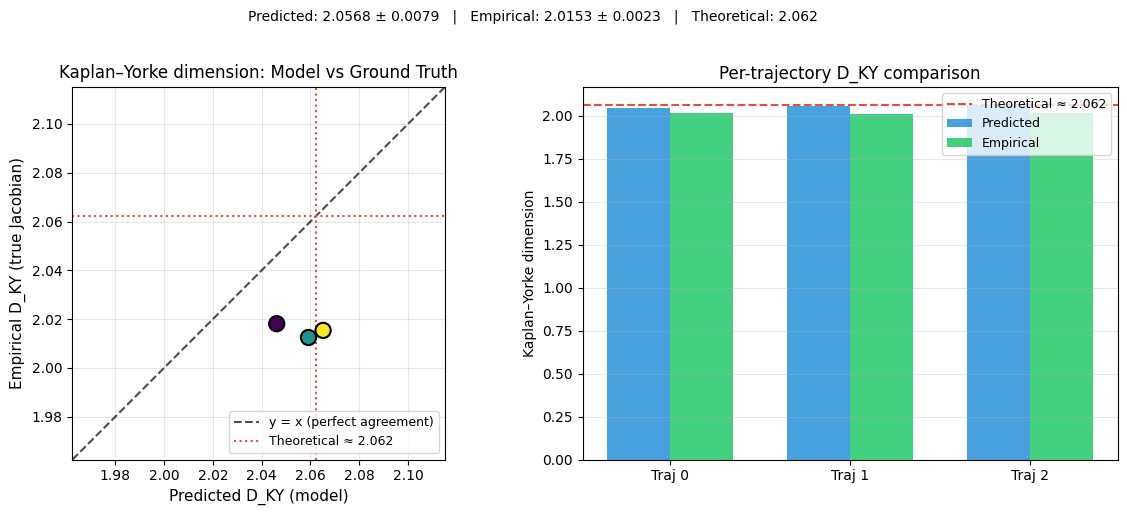

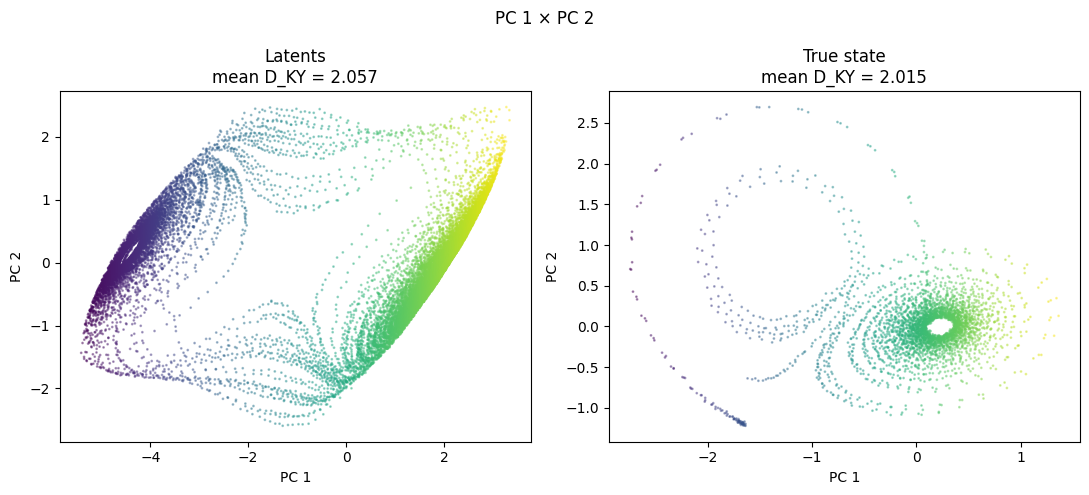

Computing prediction windows ...
Windows: 636 — nMSE min=6.7914, median=9.4482, mean=9.3811, max=13.7226


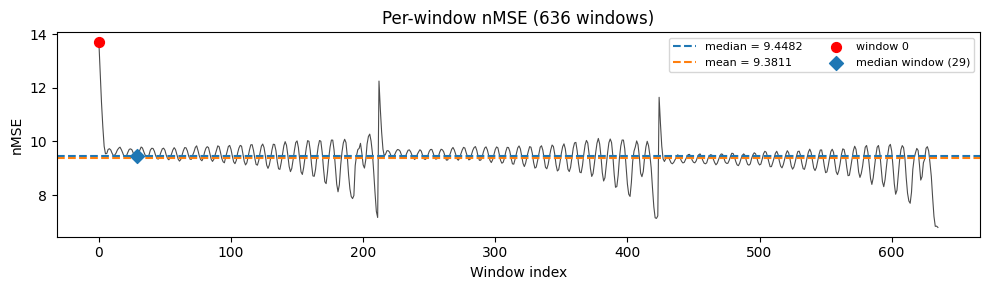

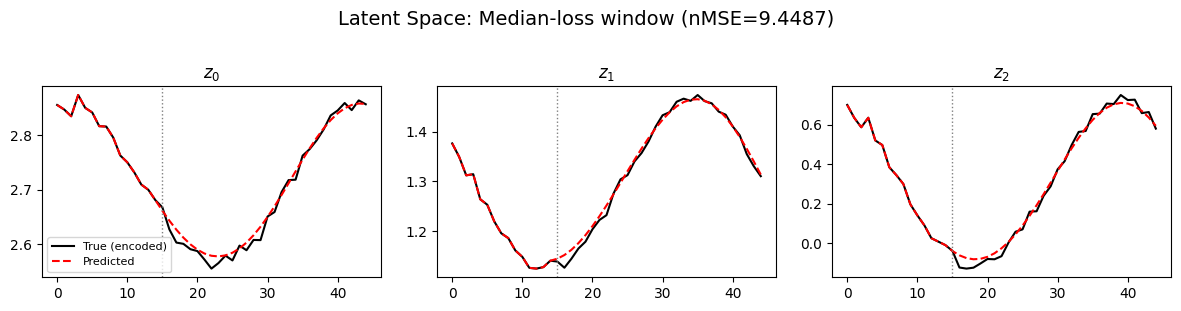

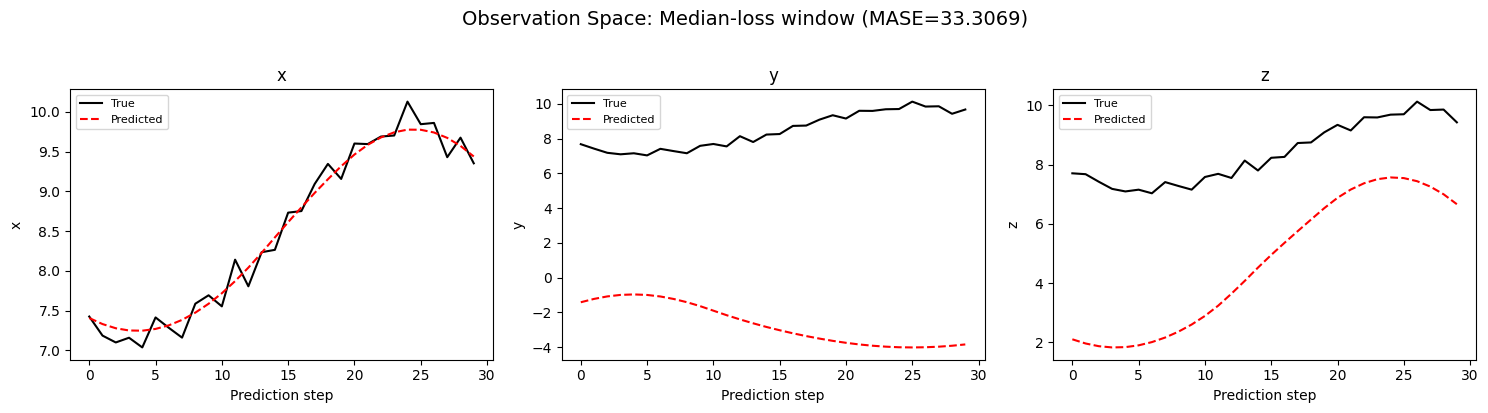

Computing long trajectory prediction ...


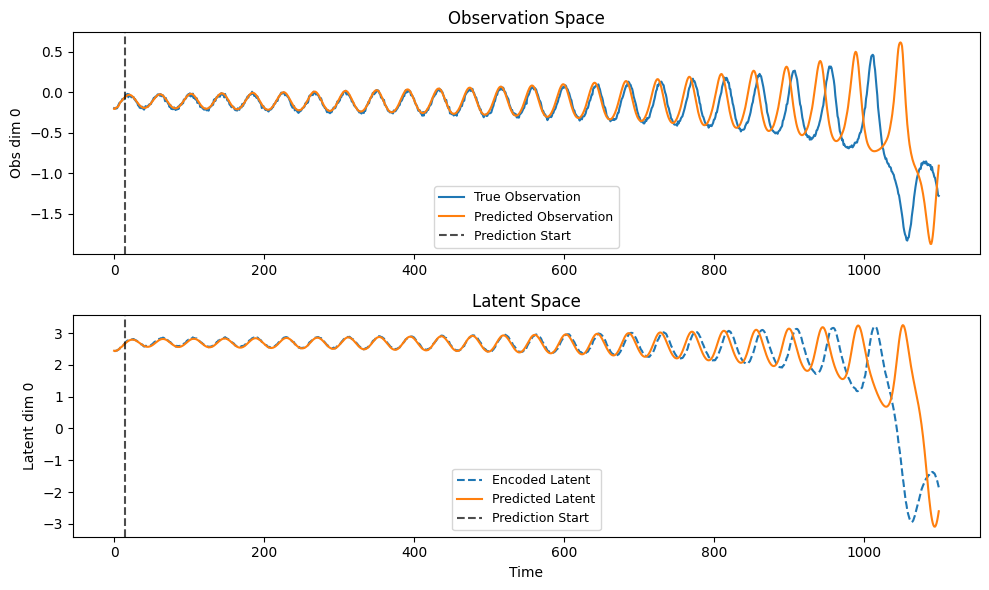

Computing encoder/decoder Jacobians ...
encoder_jacobian: (128, 100, 100)
decoder_jacobian: (128, 100, 100)


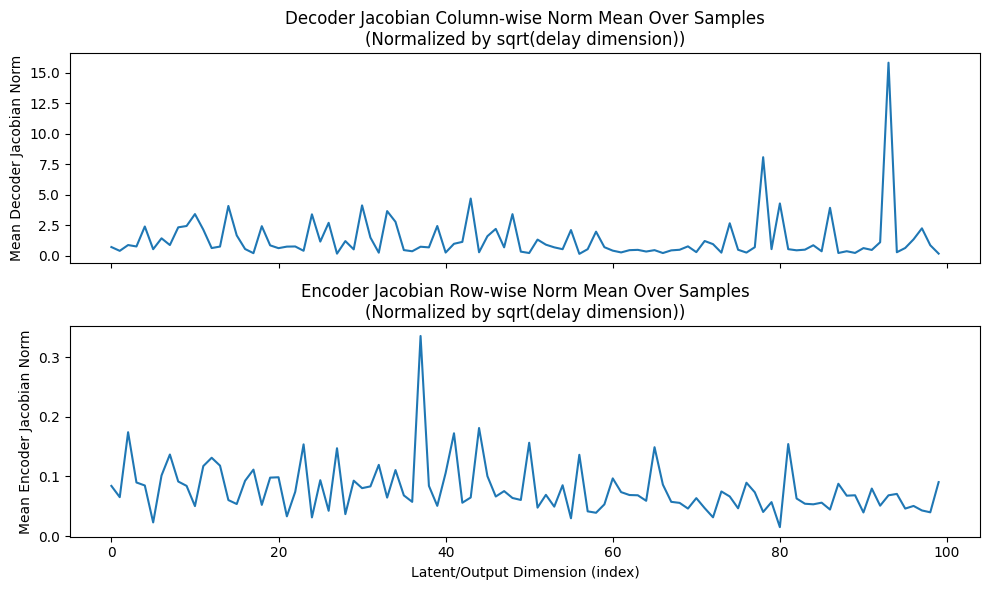

Computing amplification loss ...
Amplification loss — True state: 0.000219
Amplification loss — Latent:     0.000181


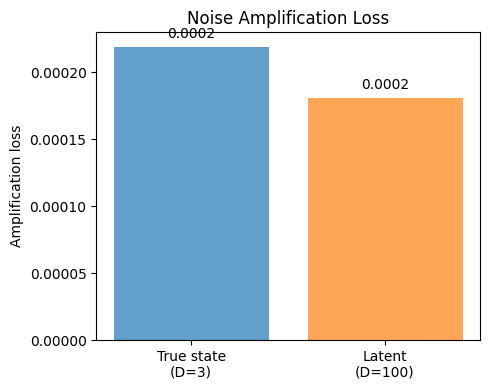

HTML report saved to: ../reports/2026-03-26_21-40-07__sweep_from_scratch_spline_coupling_lc_9vals__klNNone_1.0__klD0_0.0001_0.001_0.01_0.1_1__te0.0_enc_warmup_5_vaetrue__zpe8l5ay.html


In [41]:
from JacobianODE.jacobians.run_analytics import run_analytics

run_analytics(
    wandb_entity="JacobianODE",
    wandb_project=WANDB_PROJECT,
    wandb_group=WANDB_GROUP,
    run_id=best_run_id,
    save_dir="/orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/latent_jac_runs",
    true_lyapunov=[0.91, 0.0, -14.57],
    output=["show", "html"],   # or "save", or "return"
    # output="show",
    output_dir="../reports",
)